Accuracy test of seq vs par

In [1]:
from jax import config
config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax.numpy as jnp

In [2]:
from cmap.clqt_jax import CLQT
from cmap.nonlinear_iclqt import par_iterate
from cmap.nonlinear_iclqt import seq_iterate
from cmap.initial_guess_nonlinear import intial_guess
from cmap.linear_estimation_problem import Estimation
from cmap.convert_est_clqt import est_to_clqt

In [3]:
from nonlinear_model_ct_data import make_ct_data
from nonlinear_statespace_ct import f,h

In [4]:

T=1.0    

pos_std = 1e-1
vel_std = 1e-1
omega_std = 2e-1

sigma_v=5e-4
sigma_omega=0.02    

r_range=0.005
r_bearing=0.001
        
R=lambda t: jnp.array([[r_range**2 ,0],[0, r_bearing**2]])  
P0 = jnp.diag(jnp.array([pos_std**2, pos_std**2, vel_std**2, vel_std**2, omega_std**2]))
W = lambda t: jnp.eye(3)
L = lambda t:  jnp.array([
        [ 0.0, 0.0,0.0],
        [ 0.0, 0.0,0.0],
        [sigma_v,0.0,0.0],
        [0.0,sigma_v,0.0],
        [0.0,0.0,sigma_omega]
    ])
Q = lambda t: L(t) @ W(t) @ L(t).T
c = lambda t: jnp.zeros((5,))
r = lambda t: jnp.zeros((2,))
m0 = jnp.array([5.0, 5.0, 0.0, 0.3, jnp.deg2rad(0.0)])
vT = jnp.linalg.solve(P0, m0)




In [5]:
def accuracy_test_nonlinear_ct(steps,blocks,steps_all,T):
    dt=T/steps_all
    
    ST = jnp.linalg.solve(P0,jnp.eye(5))
    F = lambda  t: jnp.eye(5)
    H = lambda  t: jnp.array([[1.0, 0.0, 0.0, 0.0,0.0],
                                        [0.0, 1.0, 0.0, 0.0,0.0]])
    
    X,y_discrete=make_ct_data(m0, P0, f, h ,L(0), steps_all,dt,sigma_v,sigma_omega,r_range,r_bearing,seed=123)
    est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, m0, T)
    
    F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
    clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)

    x, u = intial_guess(m0, steps_all)

    x_seq = x
    u_seq = u
    x_par = x
    u_par = u

    niter=2
    t0=0.0
    ST=clqt.ST

    for i in range(niter):
        x_seq  = seq_iterate(clqt , steps, blocks, f, h , x_seq,t0,diffeq_solver='euler')

    for i in range(niter):
        x_par = par_iterate(clqt , steps, blocks, f , h , x_par,t0,diffeq_solver='euler')

    plt.plot(x_seq[:,0],x_seq[:,1],label='Sequential estimate')
    plt.plot(x_par[:,0],x_par[:,1],label='Parallel estimate')
    
    plt.legend()

    relative_error = (
    jnp.linalg.norm(x_seq - x_par)
    / jnp.linalg.norm(x_seq)
    )
    
    print(relative_error)


    return relative_error


Variant number of blocks sizes

In [6]:
steps_all=1000000

In [7]:
blocks=steps_all//5
steps=steps_all//blocks
print(blocks,steps,steps_all)

200000 5 1000000


3.608333674818036e-07


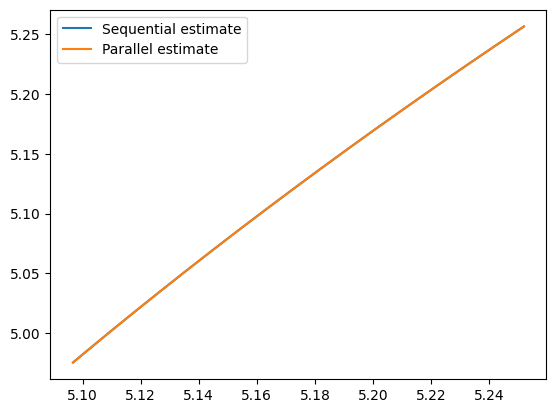

In [8]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

In [9]:
blocks=steps_all//10
steps=steps_all//blocks
print(blocks,steps,steps_all)

100000 10 1000000


3.6083220974861127e-07


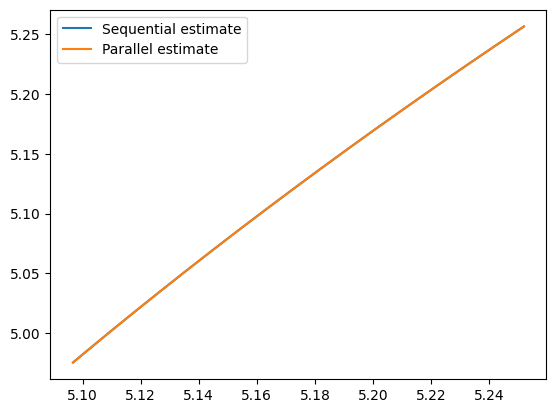

In [10]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

In [11]:
blocks=steps_all//100
steps=steps_all//blocks
print(blocks,steps,steps_all)

10000 100 1000000


3.6081206945173024e-07


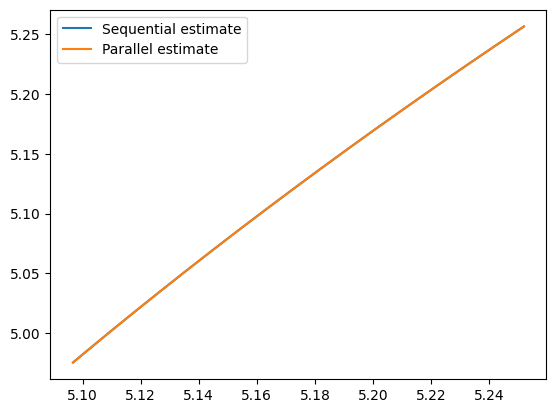

In [12]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks,steps_all,T)

In [13]:
blocks=steps_all//1000
steps=steps_all//blocks
print(blocks,steps,steps_all)

1000 1000 1000000


3.6061437090253454e-07


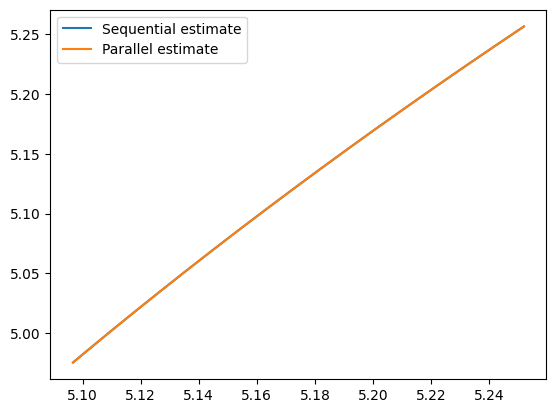

In [14]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

In [15]:
blocks=steps_all//10000
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 10000 1000000


3.58641246488865e-07


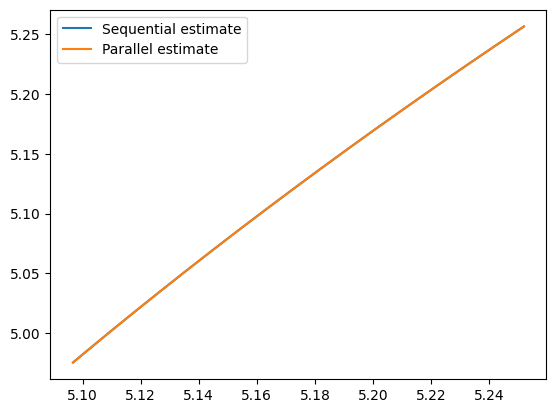

In [16]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

In [17]:
blocks=steps_all//10000
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 10000 1000000


3.58641246488865e-07


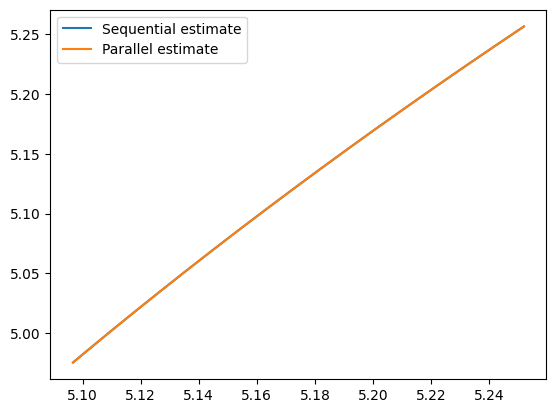

In [18]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

Variant number of total steps

In [19]:
steps_all=5000

In [20]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50 5000


7.624099573631788e-05


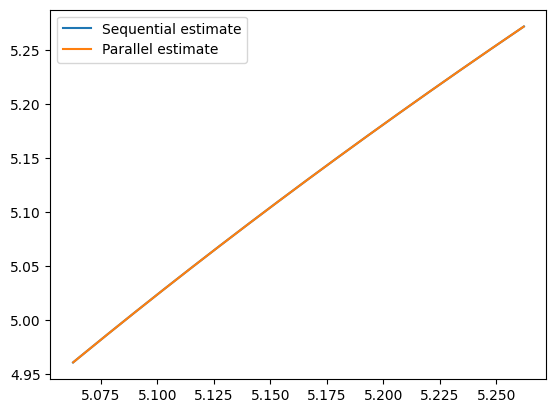

In [21]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

In [22]:
steps_all=50000

In [23]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 500 50000


7.360665526145961e-06


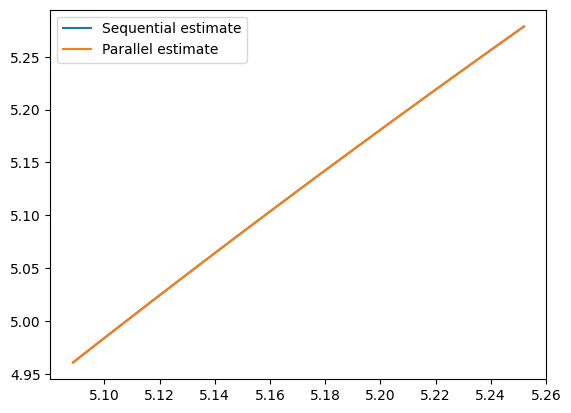

In [24]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

In [25]:
steps_all=500000

In [26]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 5000 500000


9.795464381122406e-07


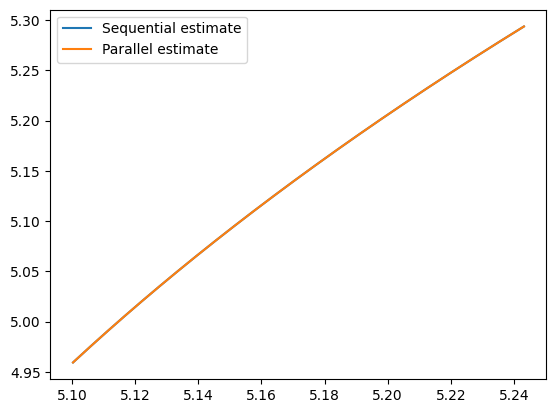

In [27]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

In [28]:
steps_all=5000000

In [29]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50000 5000000


8.898632525243265e-08


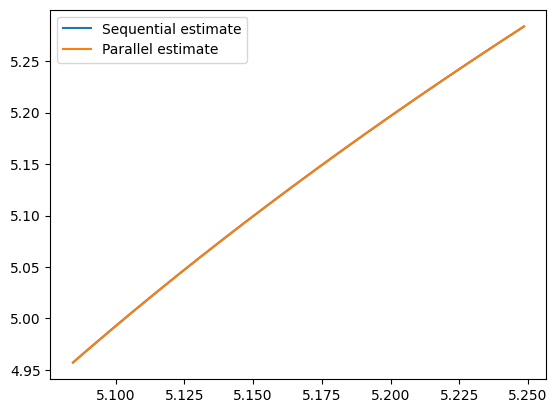

In [30]:
relative_error = accuracy_test_nonlinear_ct(steps, blocks, steps_all,T)

Variant number of total steps with Heun

In [31]:
def accuracy_test_nonlinear_ct_heun(steps,blocks,steps_all,T):
    dt=T/steps_all
    
    ST = jnp.linalg.solve(P0,jnp.eye(5))
    F = lambda  t: jnp.eye(5)
    H = lambda  t: jnp.array([[1.0, 0.0, 0.0, 0.0,0.0],
                                        [0.0, 1.0, 0.0, 0.0,0.0]])
    
    X,y_discrete=make_ct_data(m0, P0, f, h ,L(0), steps_all,dt,sigma_v,sigma_omega,r_range,r_bearing,seed=123)
    est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, m0, T)
    
    F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
    clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)

    x, u = intial_guess(m0, steps_all)

    x_seq = x
    u_seq = u
    x_par = x
    u_par = u

    niter=2
    t0=0.0
    ST=clqt.ST

    for i in range(niter):
        x_seq  = seq_iterate(clqt , steps, blocks, f, h , x_seq,t0,diffeq_solver='heun')

    for i in range(niter):
        x_par = par_iterate(clqt , steps, blocks, f , h , x_par,t0,diffeq_solver='heun')

    plt.plot(x_seq[:,0],x_seq[:,1],label='Sequential estimate')
    plt.plot(x_par[:,0],x_par[:,1],label='Parallel estimate')
    
    plt.legend()

    relative_error = (
    jnp.linalg.norm(x_seq - x_par)
    / jnp.linalg.norm(x_seq)
    )
    
    print(relative_error)


    return relative_error


In [32]:
steps_all=5000

In [33]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50 5000


2.1492068680839786e-08


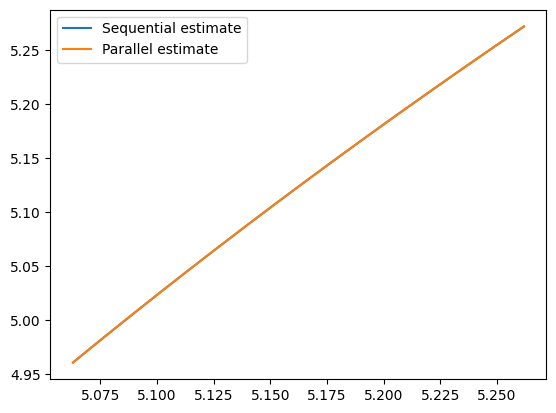

In [34]:
relative_error=accuracy_test_nonlinear_ct_heun(steps, blocks, steps_all,T)

In [35]:
steps_all=50000

In [36]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 500 50000


2.7615830168554385e-10


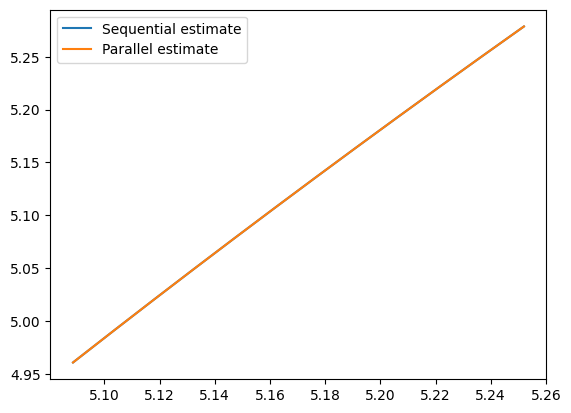

In [37]:
relative_error=accuracy_test_nonlinear_ct_heun(steps, blocks, steps_all,T)

In [38]:
steps_all=500000

In [39]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 5000 500000


4.949442858755285e-12


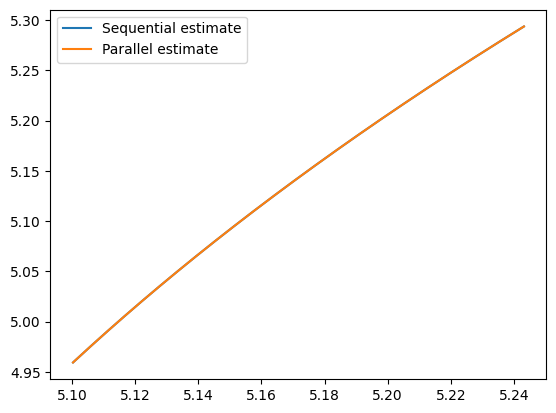

In [40]:
relative_error=accuracy_test_nonlinear_ct_heun(steps, blocks, steps_all,T)

In [41]:
steps_all=5000000

In [42]:
blocks=100
steps=steps_all//blocks
print(blocks,steps,steps_all)

100 50000 5000000


2.6677207429208945e-11


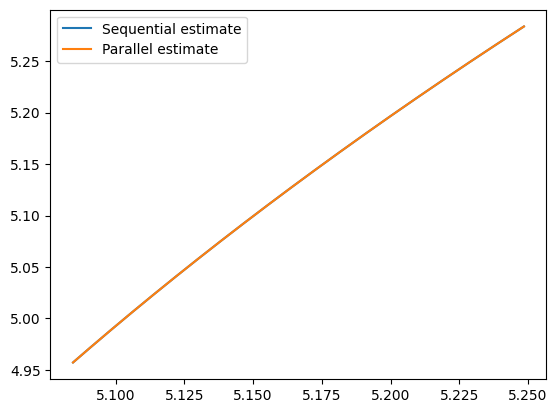

In [43]:
relative_error=accuracy_test_nonlinear_ct_heun(steps, blocks, steps_all,T)